<a href="https://colab.research.google.com/github/Sebastian1657/SILaboratories/blob/main/SI_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [71]:
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

In [72]:
def scale(image, label):
    image = tf.cast(image, tf.float32)
    image /= 255.
    return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

In [73]:
BUFFER_SIZE = 1000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [74]:
BATCH_SIZE = 100
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)
validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [75]:
input_size = 784 # 28x28 px
output_size = 10 # number of cyphers
hidden_layer_size = 50

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(output_size, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [76]:
NUM_EPOCHS = 30
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)
model.fit(train_data,
          epochs=NUM_EPOCHS,
          callbacks=[early_stopping],
          validation_data=(validation_inputs, validation_targets),
          verbose=1
          )

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8773 - loss: 0.4205 - val_accuracy: 0.9345 - val_loss: 0.2234
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9450 - loss: 0.1878 - val_accuracy: 0.9497 - val_loss: 0.1693
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9567 - loss: 0.1480 - val_accuracy: 0.9555 - val_loss: 0.1528
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9650 - loss: 0.1213 - val_accuracy: 0.9587 - val_loss: 0.1379
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9697 - loss: 0.1040 - val_accuracy: 0.9640 - val_loss: 0.1252
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9731 - loss: 0.0911 - val_accuracy: 0.9610 - val_loss: 0.1271
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9757 - loss: 0.0807 - val_accuracy: 0.9630 - val_loss: 0.1226
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9781 - loss: 0.0721 - val_accuracy:

In [77]:
test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 989ms/step - accuracy: 0.9667 - loss: 0.1186
Test loss: 0.12. Test accuracy: 96.67%


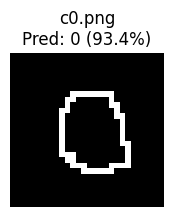

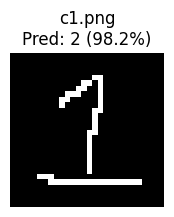

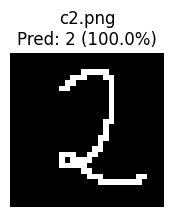

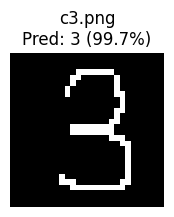

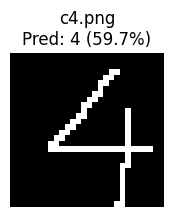

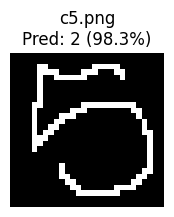

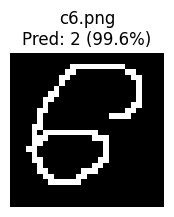

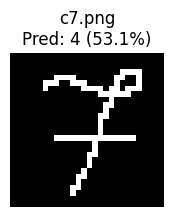

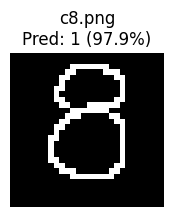

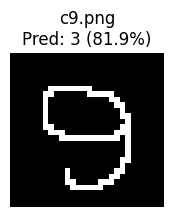

In [78]:
import os

path_to_folder = '/content/sample_data/cyphers/'
image_files = [f for f in os.listdir(path_to_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if not image_files:
    print(f"Nie znaleziono obrazów w folderze: {path_to_folder}")
else:
    for filename in sorted(image_files):
        path_to_image = os.path.join(path_to_folder, filename)

        try:
            img = cv2.imread(path_to_image)
            if img is None:
                continue

            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img_resized = cv2.resize(img_gray, (28, 28), interpolation=cv2.INTER_AREA)

            # Normalizacja i rzutowanie na float32
            img_final = img_resized.astype('float32') / 255.0

            # Przygotowanie tensora o kształcie (1, 28, 28, 1)
            img_tensor = tf.convert_to_tensor(img_final)
            img_tensor = tf.expand_dims(img_tensor, axis=0)    # (1, 28, 28)
            img_tensor = tf.expand_dims(img_tensor, axis=-1)   # (1, 28, 28, 1)

            prediction = model.predict(img_tensor, verbose=0)
            predicted_digit = np.argmax(prediction)
            confidence = np.max(prediction)

            # Wizualizacja
            plt.figure(figsize=(2, 2))
            plt.imshow(img_resized, cmap='gray')
            plt.title(f'{filename}\nPred: {predicted_digit} ({confidence*100:.1f}%)')
            plt.axis('off')
            plt.show()

        except Exception as e:
            print(f"Błąd przy pliku {filename}: {e}")